
Ti_R1s(r) =
+201.9570 * exp(-22.7314 r)
+143.5662 * r * exp(-19.4596 r)
+0.4187 * r * exp(-8.9861 r)
+478.2586 * r^2 * exp(-27.9364 r)
-0.0629 * r^2 * exp(-6.6279 r)
-0.0213 * r^2 * exp(-4.6765 r)
+0.0013 * r^2 * exp(-3.1621 r)
-2.0611 * r^3 * exp(-10.6755 r)
-0.0000 * r^3 * exp(-1.8546 r)
+0.0000 * r^3 * exp(-1.2210 r)
-0.0000 * r^3 * exp(-0.8395 r)

Ti_R2s(r) =
-59.6807 * exp(-22.7314 r)
-326.4988 * r * exp(-19.4596 r)
+284.7512 * r * exp(-8.9861 r)
-65.1574 * r^2 * exp(-27.9364 r)
+25.9331 * r^2 * exp(-6.6279 r)
-0.7443 * r^2 * exp(-4.6765 r)
+0.0726 * r^2 * exp(-3.1621 r)
+303.4168 * r^3 * exp(-10.6755 r)
-0.0007 * r^3 * exp(-1.8546 r)
+0.0001 * r^3 * exp(-1.2210 r)
-0.0000 * r^3 * exp(-0.8395 r)

Ti_R3s(r) =
-21.3369 * exp(-22.7314 r)
-133.7058 * r * exp(-19.4596 r)
+119.2625 * r * exp(-8.9861 r)
-58.5008 * r^2 * exp(-27.9364 r)
+35.4424 * r^2 * exp(-6.6279 r)
-55.1415 * r^2 * exp(-4.6765 r)
-14.7416 * r^2 * exp(-3.1621 r)
+403.3873 * r^3 * exp(-10.6755 r)
-0.0150 * r^3 * exp(-1.

/tmp/ipykernel_5649/787954399.py:129: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)


Norm 1s = 0.9995616571794764
Norm 2s = 0.9999679392846239
Norm 2p = 0.9999991975294334
Norm 3s = 1.0008786119730617
Norm 3p = 0.9999994888077669
Norm 3d = 1.0000016721102245
Norm 4s = 1.0000003445891974
           Q  J_1s_one_electron  J_2s_one_electron  J_3s_one_electron  \
0       0.00           0.039863       1.549997e-01       4.415521e-01   
1       0.05           0.039862       1.549620e-01       4.406077e-01   
2       0.10           0.039860       1.548489e-01       4.377887e-01   
3       0.15           0.039857       1.546606e-01       4.331362e-01   
4       0.20           0.039852       1.543974e-01       4.267171e-01   
...      ...                ...                ...                ...   
1996   99.80           0.000002       2.234903e-07       2.878650e-08   
1997   99.85           0.000002       2.225041e-07       2.865935e-08   
1998   99.90           0.000002       2.215212e-07       2.853263e-08   
1999   99.95           0.000002       2.205416e-07       2.840633e-

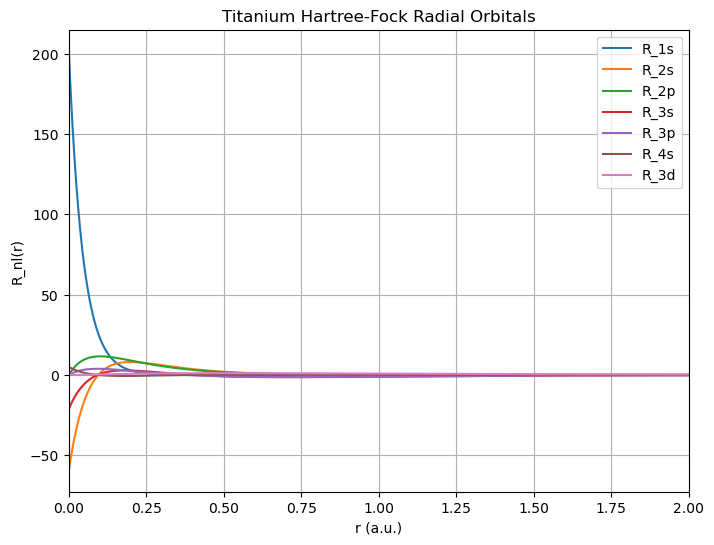

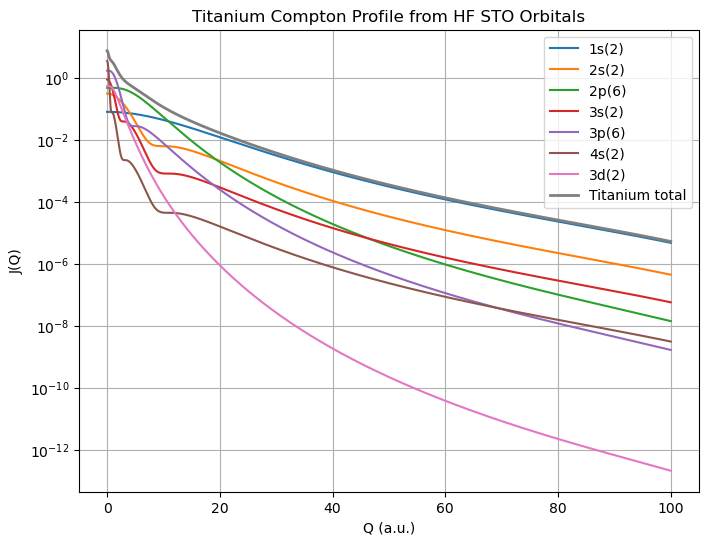

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Titanium Hartree-Fock STO data
# Ti: 1s(2) 2s(2) 2p(6) 3s(2) 3p(6) 3d(2) 4s(2)
# Format: (n_j, Z_j, C_j)
# =====================================================

titanium_1s = [
    (1,22.7314,  0.931729),
    (2,19.4596,  0.074430),
    (2, 8.9861,  0.001498),
    (3,27.9364,  0.009843),
    (3, 6.6279, -0.000199),
    (3, 4.6765, -0.000228),
    (3, 3.1621,  0.000055),
    (4,10.6755, -0.000431),
    (4, 1.8546, -0.000019),
    (4, 1.2210,  0.000013),
    (4, 0.8395, -0.000005),
]

titanium_2s = [
    (1,22.7314, -0.275337),
    (2,19.4596, -0.169269),
    (2, 8.9861,  1.018751),
    (3,27.9364, -0.001341),
    (3, 6.6279,  0.082054),
    (3, 4.6765, -0.007982),
    (3, 3.1621,  0.003062),
    (4,10.6755,  0.063448),
    (4, 1.8546, -0.000370),
    (4, 1.2210,  0.000236),
    (4, 0.8395, -0.000081),
]

titanium_3s = [
    (1,22.7314, -0.098438),
    (2,19.4596, -0.069318),
    (2, 8.9861,  0.426684),
    (3,27.9364, -0.001204),
    (3, 6.6279,  0.112142),
    (3, 4.6765, -0.591312),
    (3, 3.1621, -0.621860),
    (4,10.6755,  0.084353),
    (4, 1.8546, -0.008255),
    (4, 1.2210,  0.002364),
    (4, 0.8395, -0.000615),
]

titanium_4s = [
    (1,22.7314,  0.022864),
    (2,19.4596,  0.016391),
    (2, 8.9861, -0.101044),
    (3,27.9364,  0.000273),
    (3, 6.6279, -0.030640),
    (3, 4.6765,  0.167643),
    (3, 3.1621,  0.159930),
    (4,10.6755, -0.022705),
    (4, 1.8546, -0.292090),
    (4, 1.2210, -0.531732),
    (4, 0.8395, -0.295994),
]

titanium_2p = [
    (2,33.3883,  0.000991),
    (2,13.4246,  0.337047),
    (2, 6.9860,  0.419748),
    (2, 3.0695,  0.004328),
    (3,10.7125,  0.294936),
    (3, 2.5803, -0.000789),
    (3, 1.6116,  0.000126),
]

titanium_3p = [
    (2,33.3883,  0.000249),
    (2,13.4246,  0.073107),
    (2, 6.9860,  0.475457),
    (2, 3.0695, -0.866201),
    (3,10.7125,  0.013483),
    (3, 2.5803, -0.343747),
    (3, 1.6116, -0.025352),
]

titanium_3d = [
    (3,10.4755, 0.016004),
    (3, 5.2370, 0.172840),
    (3, 3.1849, 0.375781),
    (3, 1.9290, 0.424201),
    (3, 1.1952, 0.170623),
]
# =====================================================
# STO normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================

def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R
# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 120.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build Titanium radial orbitals
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
        elif n == 4:
            print(f"{A:+.4f} * r^3 * exp(-{Z:.4f} r)")
            
R1s = R_nl(r, titanium_1s)
R2s = R_nl(r, titanium_2s)
R3s = R_nl(r, titanium_3s)
R4s = R_nl(r, titanium_4s)
R2p = R_nl(r, titanium_2p)
R3p = R_nl(r, titanium_3p)
R3d = R_nl(r, titanium_3d)

print_R_formula(titanium_1s, "Ti_R1s")
print_R_formula(titanium_2s, "Ti_R2s")
print_R_formula(titanium_3s, "Ti_R3s")
print_R_formula(titanium_4s, "Ti_R4s")
print_R_formula(titanium_2p, "Ti_R2p")
print_R_formula(titanium_3p, "Ti_R3p")
print_R_formula(titanium_3d, "Ti_R3d")
# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_3s = chi_p(p, r, R3s, l=0)
chi_4s = chi_p(p, r, R4s, l=0)
chi_2p = chi_p(p, r, R2p, l=1)
chi_3p = chi_p(p, r, R3p, l=1)
chi_3d = chi_p(p, r, R3d, l=2)


# =====================================================
# Momentum densities and Compton profiles
# =====================================================
I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_3s, J_3s = calculate_J(p, chi_3s, Q)
I_4s, J_4s = calculate_J(p, chi_4s, Q)
I_2p, J_2p = calculate_J(p, chi_2p, Q)
I_3p, J_3p = calculate_J(p, chi_3p, Q)
I_3d, J_3d = calculate_J(p, chi_3d, Q)

print("Norm 1s =", np.trapezoid(I_1s, p))
print("Norm 2s =", np.trapezoid(I_2s, p))
print("Norm 2p =", np.trapezoid(I_2p, p))
print("Norm 3s =", np.trapezoid(I_3s, p))
print("Norm 3p =", np.trapezoid(I_3p, p))
print("Norm 3d =", np.trapezoid(I_3d, p))
print("Norm 4s =", np.trapezoid(I_4s, p))

# Titanium has 1s(2) 2s(2) 2s(2) 2p(6) 3s(2) 3p(6) 3d(2) 4s(2)
J_total = 2*J_1s + 2*J_2s + 6*J_2p + 2*J_3s + 6*J_3p + 2*J_3d + 2*J_4s

# =====================================================
# Print and save table
# =====================================================
table = pd.DataFrame({
    "Q": Q,
    "J_1s_one_electron": J_1s,
    "J_2s_one_electron": J_2s,
    "J_3s_one_electron": J_3s,
    "J_2p_one_electron": J_2p,
    "J_3p_one_electron": J_3p,
    "J_3d_one_electron": J_3d,
    "J_4s_one_electron": J_4s,
    "J_1s(2)": 2*J_1s,
    "J_2s(2)": 2*J_2s,
    "J_2p(6)": 6*J_2p,
    "J_3s(2)": 2*J_3s,
    "J_3p(6)": 6*J_3p,
    "J_4s(2)": 2*J_4s,
    "J_3d(2)": 2*J_3d,
    "J_total_Titanium": J_total
    })
print(table)
table.to_csv("Titanium_HF_Compton_profile.csv", index = False)

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.plot(r, R3s, label="R_3s")
plt.plot(r, R3p, label="R_3p")
plt.plot(r, R4s, label="R_4s")
plt.plot(r, R3d, label="R_3d")
plt.xlim(0, 2)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("Titanium Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================
plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 6*J_2p, label="2p(6)")
plt.plot(Q, 2*J_3s, label="3s(2)")
plt.plot(Q, 6*J_3p, label="3p(6)")
plt.plot(Q, 2*J_4s, label="4s(2)")
plt.plot(Q, 2*J_3d, label="3d(2)")
plt.plot(Q, J_total, label="Titanium total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("Titanium Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()